In [1]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

%matplotlib widget


In [2]:
condition = "4mod_basic_s126"
checkpoint_epoch = 0
n_samples_test = 50
split = "test"


In [3]:
experiment_name = get_experiment_name(condition, "biased_00", 0)
modules = get_setup_modules('syn', experiment_name)
global_workspace = get_global_workspace("syn", experiment_name, epoch=checkpoint_epoch, modules=modules)
data_module = get_data_module("syn",  experiment_name, modules=modules)

test_samples = get_data_samples(data_module, n_samples_test, split=split)
original_colors = test_samples[frozenset({'color'})]['color']
original_v_latents = test_samples[frozenset({'v_latents'})]['v_latents']
cat = test_samples[frozenset({'cat'})]['cat']

domain_mods = global_workspace.domain_mods
gw_mod = global_workspace.gw_mod
latent_domains = global_workspace.encode_domains(test_samples)

visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods["v_latents"])
original_images_rgb = visual_module.decode_images(original_v_latents)


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
/home/luc

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/4mod_basic_s126_biased_00/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/4mod_basic_s126_biased_00/checkpoints/last.ckpt


In [4]:
# cat to position to v_latents

# cat_to_position
domain_name_source = 'cat'
domain_name_target = 'position'
latents_source = latent_domains[frozenset({domain_name_source})]

z_from_cat = gw_mod.encode(latents_source)[domain_name_source]
x_pred_cat_to_position = gw_mod.decode(z_from_cat, domains={domain_name_target})

# translation_position_to_v_latents

domain_name_source = 'position'
domain_name_target = 'v_latents'

z_from_cat_to_postition = gw_mod.encode(x_pred_cat_to_position)[domain_name_source]
x_pred_cat_to_position_to_v = gw_mod.decode(z_from_cat_to_postition, domains={domain_name_target})


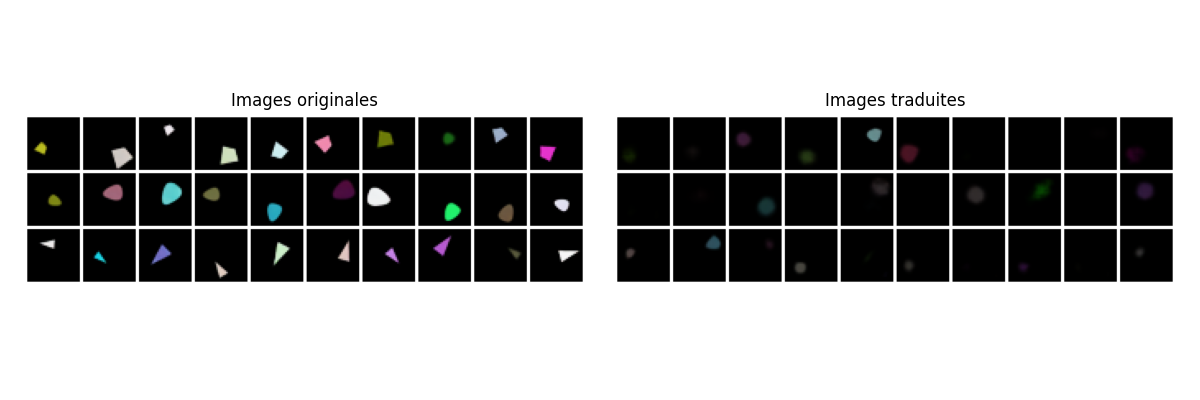

In [5]:
# fustion:cat + color to v_latents
latents_source = latent_domains[frozenset({'color', 'cat', 'position', 'v_latents'})]
p = 0.5

gw_latents = gw_mod.encode(latents_source)
z_cat_color = 0.5*gw_latents['color'] + 0.5*gw_latents['cat']

x_pred_cat_color_to_v = gw_mod.decode(z_cat_color, domains={'v_latents'})['v_latents']
decoded_images_f = visual_module.decode_images(x_pred_cat_color_to_v)

fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 10), get_n_per_category(decoded_images_f, cat, 10))
plt.show()


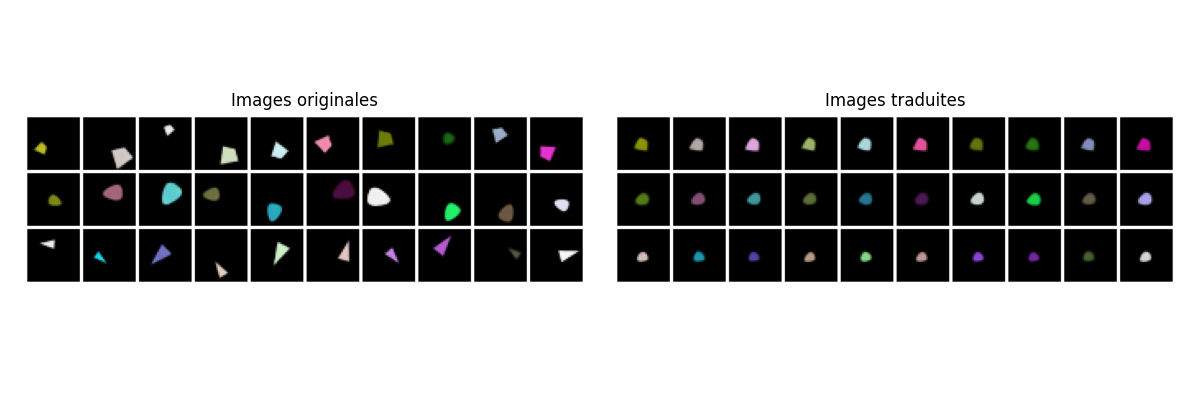

In [6]:
p = 0.5
z_fusion = 0.5*z_cat_color+ 0.5*z_from_cat_to_postition
fusion = gw_mod.decode(z_fusion, domains={'v_latents'})['v_latents']

decoded_images_t= visual_module.decode_images(fusion)

fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 10), get_n_per_category(decoded_images_t, cat, 10))
plt.show()


In [7]:
# del original_images_rgb
# del decoded_images_dcy
# del decoded_images_f
# del decoded_images_t
# del decoded_images_dt
# torch.cuda.empty_cache()